<a href="https://colab.research.google.com/github/AmanGupta3995377/Celebal-Week2-Assignment/blob/main/week2_aman_gupta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 Assignment - Classical Machine Learning

## Topics Covered
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- ML Pipelines
- Linear Regression
- Ridge Regression
- Lasso Regression
- Cross Validation
- Hyperparameter Tuning
- Time Series Analysis

# Importing Libraries

In [9]:
import pandas as pd

# Loading Dataset

In [10]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


# Dataset Overview

In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


# Checking Missing Values

In [12]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


# Statistical Summary

In [13]:
df.describe()

# Checking unique values in categorical columns
print("Regions:")
print(df['Region'].unique())

print("\nModels:")
print(df['Model'].unique())

print("\nSource Types:")
print(df['Source_Type'].unique())

Regions:
['Europe' 'Asia' 'North America' 'Middle East']

Models:
['Model S' 'Model X' 'Model 3' 'Model Y' 'Cybertruck']

Source Types:
['Interpolated (Month)' 'Official (Quarter)' 'Estimated (Region)']


# Exploratory Data Analysis (EDA)

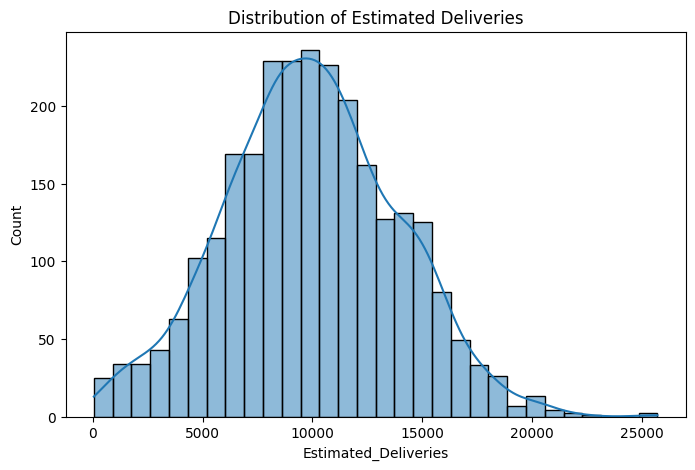

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df['Estimated_Deliveries'],
             bins=30,
             kde=True)

plt.title("Distribution of Estimated Deliveries")
plt.show()

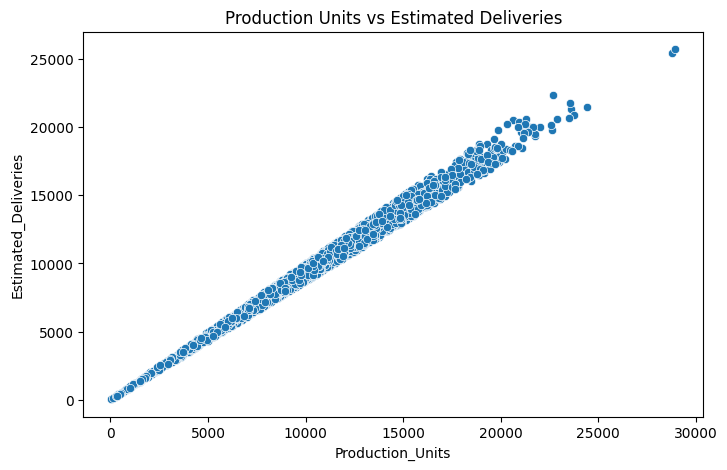

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='Production_Units',
                y='Estimated_Deliveries',
                data=df)

plt.title("Production Units vs Estimated Deliveries")
plt.show()

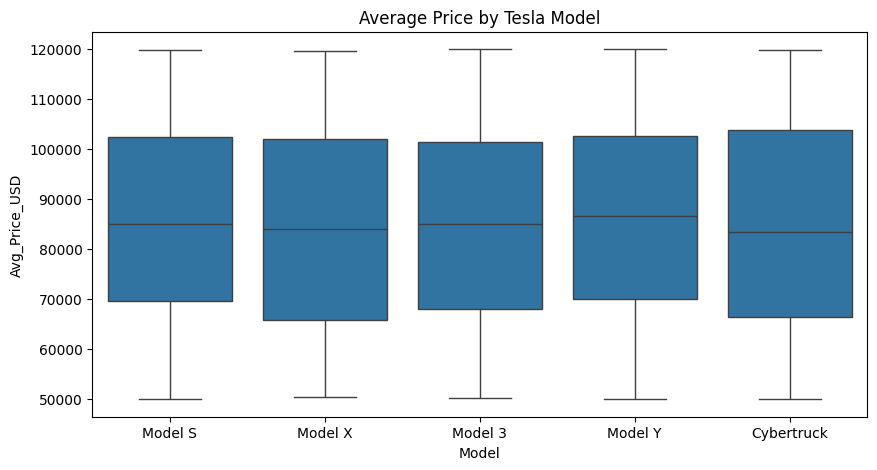

In [16]:
plt.figure(figsize=(10,5))

sns.boxplot(x='Model',
            y='Avg_Price_USD',
            data=df)

plt.title("Average Price by Tesla Model")
plt.show()

# Feature Engineering

In [28]:
# Feature Engineering
df['Delivery_Efficiency'] = (
    df['Estimated_Deliveries'] / df['Production_Units']
)

df['Price_per_km'] = (
    df['Avg_Price_USD'] / df['Range_km']
)

df['Charging_per_Region'] = (
    df['Charging_Stations'] / (df['Year'] - 2014)
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Delivery_Efficiency,Price_per_km,Charging_per_Region
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,0.984600,131.923679,1356.333333
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,0.911864,142.022032,7640.000000
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,0.915334,245.598583,2814.200000
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,0.896594,125.414199,1333.285714
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,0.914087,173.747020,4361.000000


# Defining Features and Target Variable

In [29]:
#Features and target
X = df.drop('Estimated_Deliveries', axis=1)

y = df['Estimated_Deliveries']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (2640, 14)
Target shape: (2640,)


# Identifying Numerical and Categorical Features

In [30]:
# Numerical and categorical columns

num_cols = X.select_dtypes(include=['int64', 'float64']).columns

cat_cols = X.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['Year', 'Month', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations', 'Delivery_Efficiency', 'Price_per_km',
       'Charging_per_Region'],
      dtype='object')

Categorical Columns:
Index(['Region', 'Model', 'Source_Type'], dtype='object')


# Data Preprocessing

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

#Preprocessing for numerical columns
num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

#Preprocessing for categorical columns
cat_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

#Combining preprocessing
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# Train-Test Split

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (2112, 14)
X_test: (528, 14)


In [34]:
from sklearn.linear_model import LinearRegression

# Building Pipeline

In [35]:
#Creating pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Training the model
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


# Model Predictions

In [36]:
# Predictions
y_pred = model.predict(X_test)

print("First 5 Predictions:")
print(y_pred[:5])

First 5 Predictions:
[6861.2488997  9309.5347616  9082.72695237 8921.71312096 8696.70093774]


# Model Evaluation Metrics

In [37]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [38]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 2))
print("MSE:", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R2 Score:", round(r2, 4))

MAE: 108.94
MSE: 23596.6
RMSE: 153.61
R2 Score: 0.9984


# Actual vs Predicted Visualization

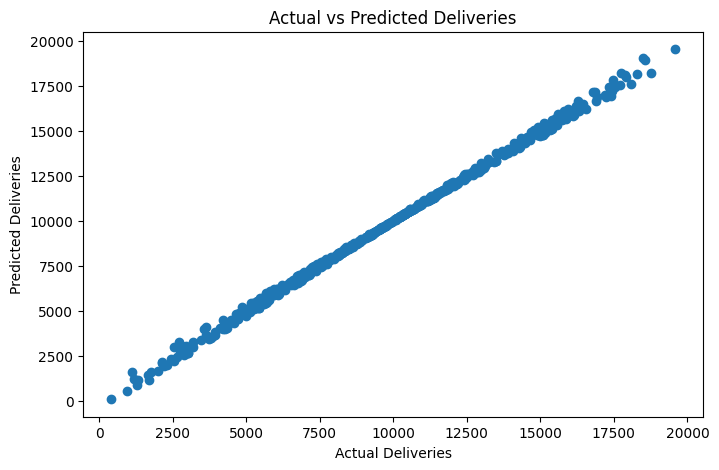

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")
plt.title("Actual vs Predicted Deliveries")
plt.show()

# Residual Analysis

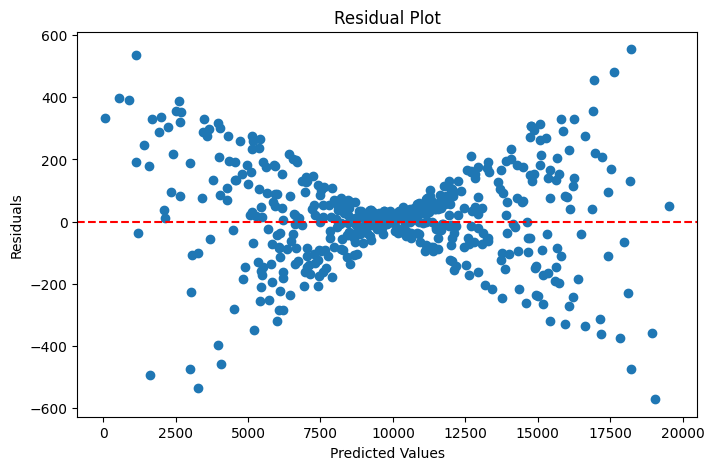

In [40]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# Regression Model Comparison

In [41]:
from sklearn.linear_model import Ridge

ridge_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge R2 Score:", round(ridge_r2, 4))

Ridge R2 Score: 0.9984


In [42]:
from sklearn.linear_model import Lasso

lasso_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso(alpha=0.1))
])

lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)
lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso R2 Score:", round(lasso_r2, 4))

Lasso R2 Score: 0.9984


In [43]:
print("Linear Regression R2:", round(r2, 4))
print("Ridge Regression R2:", round(ridge_r2, 4))
print("Lasso Regression R2:", round(lasso_r2, 4))

Linear Regression R2: 0.9984
Ridge Regression R2: 0.9984
Lasso Regression R2: 0.9984


# Cross Validation

In [44]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='r2'
)
print("Cross Validation R2 Scores:")
print(cv_scores)
print("Average CV R2:", round(cv_scores.mean(), 4))

Cross Validation R2 Scores:
[0.9985013  0.99849115 0.99824298 0.99827267 0.99854329]
Average CV R2: 0.9984


# Hyperparameter Tuning

In [45]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'regressor__alpha': [0.01, 0.1, 1, 10]
}
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])
grid_search = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=5,
    scoring='r2'
)
grid_search.fit(X_train, y_train)

print("Best Alpha:", grid_search.best_params_)
print("Best CV Score:", round(grid_search.best_score_, 4))

Best Alpha: {'regressor__alpha': 0.01}
Best CV Score: 0.9984


# Time Series Analysis

In [46]:
# Creating date column
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' + df['Month'].astype(str)
)
monthly_sales = df.groupby('Date')['Estimated_Deliveries'].mean()
monthly_sales.head()

,Estimated_Deliveries
Date,
2015-01-01,9159.00
2015-02-01,8252.65
2015-03-01,9228.35
2015-04-01,11281.15
2015-05-01,9213.20


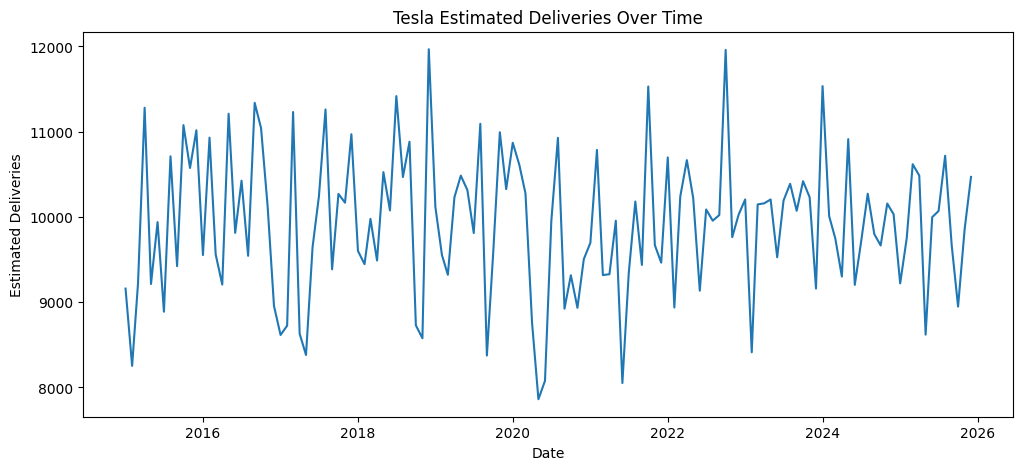

In [47]:
plt.figure(figsize=(12,5))
plt.plot(monthly_sales)
plt.title("Tesla Estimated Deliveries Over Time")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.show()

# Conclusion

In this project, I built a complete machine learning pipeline using Tesla sales and production data. I performed data cleaning, exploratory data analysis (EDA), preprocessing, and feature engineering to better understand the dataset and improve model performance.
I trained and compared Linear Regression, Ridge Regression, and Lasso Regression models. After feature engineering and hyperparameter tuning, the models achieved very strong performance with an R² score close to 0.998. I also used cross validation and time series visualization to analyze delivery trends over time and evaluate model consistency.